# 04 – Entalpia de Formação a partir dos Polinômios da NASA

A **entalpia padrão de formação** $\Delta_f H^\circ$ é a variação de entalpia
quando um mol de uma espécie é formado a partir de seus elementos em seus
estados de referência a 298,15 K e 1 bar. Por definição, ela é **zero** para um
elemento em seu estado de referência (O₂, N₂, H₂, grafite, ...).

O `pyglenn` oferece um método `calculate_formation_enthalpy` — mas, como
veremos, a coluna dedicada no banco de dados está vazia. A boa notícia: como os
polinômios da NASA ajustam a entalpia *padronizada*, podemos recuperar
$\Delta_f H^\circ$ diretamente como

$$\Delta_f H^\circ(\text{espécie}) = H^\circ(298{,}15\,\mathrm{K}),$$

isto é, simplesmente `calculate_properties(id, 298.15)["h_relative"]`.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Constante universal dos gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. O método dedicado retorna `None`

No banco de dados empacotado, a coluna `heat_of_formation_298K` nunca foi
preenchida, portanto `calculate_formation_enthalpy` retorna `None` para todas as
espécies. Ele está implementado e pronto para o caso de um banco de dados futuro
preencher essa coluna.

In [3]:
with ThermochemicalCalculator() as calc:
    for name in ["H2O", "CO2", "CH4"]:
        sid = calc.get_available_species(name, exact_match=True)[0]["id"]
        print(f"{name:5s} calculate_formation_enthalpy -> "
              f"{calc.calculate_formation_enthalpy(sid)}")

H2O   calculate_formation_enthalpy -> None
CO2   calculate_formation_enthalpy -> None
CH4   calculate_formation_enthalpy -> None


## 2. Recuperando $\Delta_f H^\circ$ do polinômio

A entalpia padronizada já contém a entalpia de formação, portanto a 298,15 K
ela *é* $\Delta_f H^\circ$. Elementos no estado de referência resultam
essencialmente zero (dentro do arredondamento do ajuste).

In [4]:
def formation_enthalpy(calc, name, T=298.15):
    """Delta_f H em T (padrão 298,15 K), em J/mol, a partir do H padronizado."""
    return calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]

with ThermochemicalCalculator() as calc:
    print("Elementos no estado de referência (devem ser ~0):")
    for el in ["O2", "N2", "H2", "C(gr)"]:
        print(f"  {el:6s} {formation_enthalpy(calc, el)/1000: .4f} kJ/mol")

Elementos no estado de referência (devem ser ~0):
  O2     -0.0000 kJ/mol
  N2      0.0000 kJ/mol
  H2     -0.0000 kJ/mol
  C(gr)   0.0000 kJ/mol


## 3. Uma tabela validada de entalpias de formação

Calculamos $\Delta_f H^\circ$ para um conjunto de espécies comuns e comparamos
com valores aceitos da literatura (CODATA / JANAF, fase gasosa). A concordância
fica bem dentro de 1 kJ/mol — os polinômios reproduzem os dados de referência
aos quais foram ajustados.

In [5]:
# Entalpias padrão de formação da literatura a 298,15 K, kJ/mol (fase gasosa)
REFERENCE = {
    "H2": 0.0, "O2": 0.0, "N2": 0.0, "C(gr)": 0.0,
    "H2O": -241.83, "CO2": -393.52, "CO": -110.53, "CH4": -74.87,
    "NH3": -45.90, "NO": 91.29, "NO2": 33.10, "C2H5OH": -235.0,
}

records = []
with ThermochemicalCalculator() as calc:
    for name, ref in REFERENCE.items():
        sid = calc.get_available_species(name, exact_match=True)[0]["id"]
        M = calc.db.get_species_data(sid)["molecular_weight"]
        dhf = formation_enthalpy(calc, name) / 1000.0
        records.append({
            "espécie": name, "M [g/mol]": M,
            "pyglenn [kJ/mol]": dhf, "referência [kJ/mol]": ref,
            "erro abs. [kJ/mol]": abs(dhf - ref),
        })

hf_df = pd.DataFrame(records).set_index("espécie")
print(hf_df.to_string())
print(f"\nMaior erro absoluto: {hf_df['erro abs. [kJ/mol]'].max():.3f} kJ/mol")

         M [g/mol]  pyglenn [kJ/mol]  referência [kJ/mol]  erro abs. [kJ/mol]
espécie                                                                      
H2           2.016            -0.000                0.000               0.000
O2          31.999            -0.000                0.000               0.000
N2          28.013             0.000                0.000               0.000
C(gr)       12.011             0.000                0.000               0.000
H2O         18.015          -241.825             -241.830               0.005
CO2         44.010          -393.508             -393.520               0.012
CO          28.010          -110.535             -110.530               0.005
CH4         16.042           -74.600              -74.870               0.270
NH3         17.031           -45.940              -45.900               0.040
NO          30.006            91.271               91.290               0.019
NO2         46.005            34.193               33.100       

## 4. Visualizando entalpias de formação

Um gráfico de barras horizontais torna evidente a divisão entre espécies
exotérmicas ($\Delta_f H^\circ$ negativo, estáveis) e endotérmicas (positivo,
energéticas). Os elementos situam-se exatamente sobre a linha do zero.

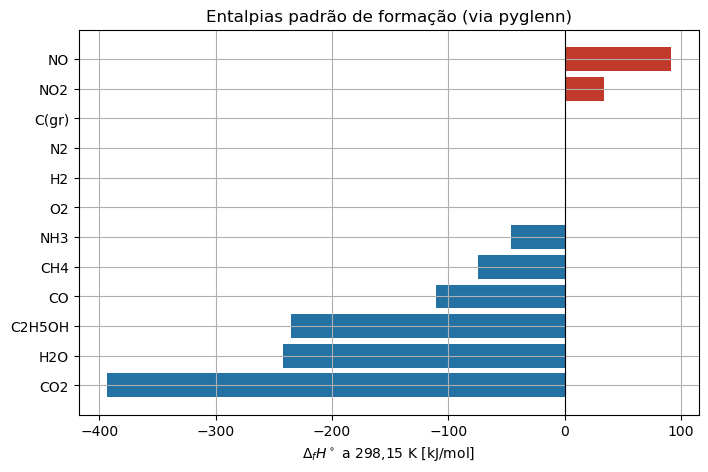

In [6]:
order = hf_df.sort_values("pyglenn [kJ/mol]")
vals = order["pyglenn [kJ/mol]"]
colors = ["#c0392b" if v > 0 else ("#7f8c8d" if abs(v) < 1e-3 else "#2471a3")
          for v in vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(order.index, vals, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(r"$\Delta_f H^\circ$ a 298,15 K [kJ/mol]")
ax.set_title("Entalpias padrão de formação (via pyglenn)")
plt.show()

## 5. Somente 298,15 K é "formação"

$\Delta_f H^\circ$ é definida a 298,15 K. A entalpia padronizada $H^\circ(T)$
continua variando com a temperatura, mas apenas seu valor a 298,15 K iguala a
entalpia de formação tabelada. Para o CO₂, plotamos $H^\circ(T)$ e destacamos
esse ponto de referência; o deslocamento vertical acima dele é a entalpia
*sensível* $H^\circ(T)-H^\circ(298{,}15)$ do notebook 03.

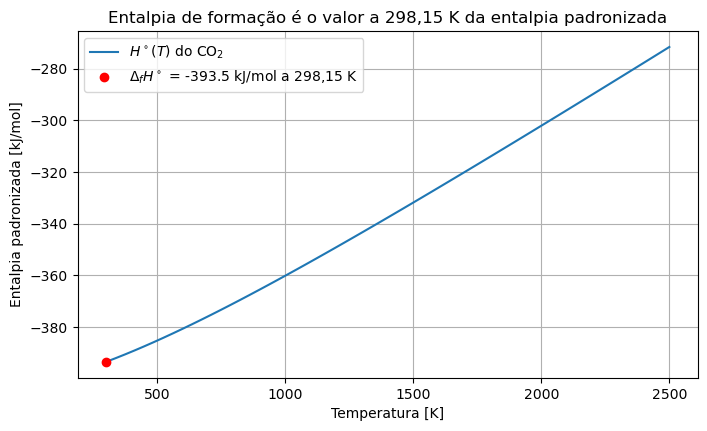

In [7]:
Tgrid = np.linspace(300, 2500, 60)
with ThermochemicalCalculator() as calc:
    co2 = calc.get_available_species("CO2", exact_match=True)[0]["id"]
    H = np.array([calc.calculate_properties(co2, t)["h_relative"] for t in Tgrid]) / 1000.0
    hf298 = formation_enthalpy(calc, "CO2") / 1000.0

fig, ax = plt.subplots()
ax.plot(Tgrid, H, label=r"$H^\circ(T)$ do CO$_2$")
ax.scatter([298.15], [hf298], color="red", zorder=5,
           label=fr"$\Delta_f H^\circ$ = {hf298:.1f} kJ/mol a 298,15 K")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("Entalpia padronizada [kJ/mol]")
ax.set_title("Entalpia de formação é o valor a 298,15 K da entalpia padronizada")
ax.legend()
plt.show()

## Resumo

- `calculate_formation_enthalpy` retorna `None` aqui (coluna do banco vazia).
- Use `calculate_properties(id, 298.15)["h_relative"]` em vez disso — ele
  equivale a $\Delta_f H^\circ$ e reproduz valores da literatura com erro
  < 1 kJ/mol.
- Como $H^\circ$ já carrega a entalpia de formação, as entalpias de reação
  tornam-se somas triviais.

**A seguir:** o notebook 05 usa exatamente isso para calcular entalpias de
reação e calores de combustão.